# District LLM Fine-Tuning

This notebook fine-tunes the district coordinator on the larger v3 chat dataset, saves validation checkpoints, reloads the best adapter, and runs offline evaluation with before/after repair metrics.


## 1. Install dependencies

Run this first in Colab after cloning or uploading the repository.


In [1]:
%%capture
import os
import re
import sys
from pathlib import Path
import torch
from datasets import load_dataset
from transformers import TrainingArguments
from trl import SFTTrainer
from peft import LoraConfig
from unsloth import FastLanguageModel

REPO_ROOT = Path('agentic-traffic')
if REPO_ROOT.exists() and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


## 2. Configure Paths And Run Mode

Set the dataset root, run preset, and checkpoint layout here. The notebook supports a short smoke test and a main A100 run.


In [ ]:
from pathlib import Path
import json

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data').exists() or (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repo root from the current working directory.')


def resolve_dataset_root(repo_root: Path) -> Path:
    candidates = [
        repo_root / 'data' / 'district_llm_dataset_v3',
        repo_root / 'outputs' / 'district_llm_dataset_v3',
        repo_root / 'data' / 'district_llm_dataset_v2',
        repo_root / 'outputs' / 'district_llm_dataset_v2',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


REPO_ROOT = find_repo_root(Path.cwd())
DATASET_ROOT = resolve_dataset_root(REPO_ROOT)
TRAIN_JSONL = DATASET_ROOT / 'train.jsonl'
VAL_JSONL = DATASET_ROOT / 'val.jsonl'
METADATA_JSON = DATASET_ROOT / 'metadata.json'
MODEL_NAME = 'unsloth/Llama-3.1-8B'
MAX_SEQ_LENGTH = 2048
LOAD_IN_4BIT = True
SEED = 3407
DATASET_NUM_PROC = 2
DEBUG_EXAMPLES = 10
MAX_EVAL_EXAMPLES = 250
ALLOW_ONLY_VISIBLE_CANDIDATES = True
MAX_TARGET_INTERSECTIONS = 3
FALLBACK_ON_EMPTY_TARGETS = True
FALLBACK_MODE = 'heuristic'
RESTRICT_TARGETS_TO_VISIBLE_SUMMARY = True
RUN_MODE = 'main_run'  # 'smoke_test' or 'main_run'
MAX_STEPS_OVERRIDE = None  # e.g. 5000 for experimentation
RESUME_FROM_CHECKPOINT = None

RUN_PRESETS = {
    'smoke_test': {
        'num_train_epochs': 1,
        'max_steps': 40,
        'per_device_train_batch_size': 2,
        'per_device_eval_batch_size': 2,
        'gradient_accumulation_steps': 4,
        'warmup_ratio': 0.03,
        'learning_rate': 2e-4,
        'logging_steps': 5,
        'eval_steps': 20,
        'save_steps': 20,
        'save_total_limit': 2,
    },
    'main_run': {
        'num_train_epochs': 2,
        'max_steps': 200
        ,
        'per_device_train_batch_size': 8,
        'per_device_eval_batch_size': 8,
        'gradient_accumulation_steps': 4,
        'warmup_ratio': 0.05,
        'learning_rate': 5e-5,
        'logging_steps': 10,
        'eval_steps': 50,
        'save_steps': 50,
        'save_total_limit': 10,
    },
}

RUN_CONFIG = dict(RUN_PRESETS[RUN_MODE])
if MAX_STEPS_OVERRIDE is not None:
    RUN_CONFIG['max_steps'] = int(MAX_STEPS_OVERRIDE)

RUN_ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'district_llm_adapter_v3' / RUN_MODE
CHECKPOINT_DIR = RUN_ARTIFACT_DIR / 'checkpoints'
ADAPTER_OUTPUT_DIR = RUN_ARTIFACT_DIR / 'adapter'
BEST_ADAPTER_DIR = ADAPTER_OUTPUT_DIR

print(f'REPO_ROOT={REPO_ROOT}')
print(f'DATASET_ROOT={DATASET_ROOT}')
print(f'RUN_MODE={RUN_MODE}')
print(json.dumps(RUN_CONFIG, indent=2, sort_keys=True))


REPO_ROOT=/root/aditya/agentic-traffic
DATASET_ROOT=/root/aditya/agentic-traffic/data/district_llm_dataset_v3
RUN_MODE=main_run
{
  "eval_steps": 50,
  "gradient_accumulation_steps": 4,
  "learning_rate": 5e-05,
  "logging_steps": 10,
  "max_steps": 200,
  "num_train_epochs": 2,
  "per_device_eval_batch_size": 8,
  "per_device_train_batch_size": 8,
  "save_steps": 50,
  "save_total_limit": 10,
  "warmup_ratio": 0.05
}


## 3. Inspect Dataset Metadata And Preview Rows

This checks that the larger constrained dataset exists and exposes candidate_intersections before training.


In [3]:
import json
from datasets import load_dataset

metadata = json.loads(METADATA_JSON.read_text())
print(json.dumps(metadata, indent=2)[:5000])

dataset = load_dataset(
    'json',
    data_files={'train': str(TRAIN_JSONL), 'val': str(VAL_JSONL)},
)
print(dataset)
print(json.dumps(dataset['train'][0], indent=2)[:2500])
print('train candidate_intersections:', len(dataset['train'][0].get('candidate_intersections', [])))


{
  "average_candidate_intersections_count": 5.2272,
  "average_target_intersections_count": 2.81336,
  "controller_family_counts": {
    "dqn": 12500
  },
  "duplicate_rows_removed": 0,
  "generation_timestamp": "2026-03-08T02:03:42.664133+00:00",
  "num_train_rows": 10000,
  "num_val_rows": 2500,
  "rows_per_city": {
    "city_0001": 8449,
    "city_0002": 1551,
    "city_0009": 2500
  },
  "rows_per_district_type": {
    "commercial": 4484,
    "industrial": 2376,
    "mixed": 1545,
    "residential": 4095
  },
  "rows_per_scenario": {
    "accident": 1704,
    "construction": 1704,
    "district_overload": 1222,
    "evening_rush": 1704,
    "event_spike": 1207,
    "morning_rush": 2119,
    "normal": 2840
  },
  "schema_version": "district_action_v1_messages_v3_candidates",
  "teacher_sources": [
    {
      "checkpoint_path": "artifacts/dqn_shared/best_validation.pt",
      "controller_family": "dqn",
      "controller_id": "best_validation",
      "controller_type": "rl_checkpoi

## 4. Load The Base Model With Unsloth

This loads the base model and attaches the LoRA adapter for SFT.


In [4]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    lora_alpha=16,
    lora_dropout=0.05,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)


==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 5.2.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


/root/conda_envs/traffic-llm/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=23524) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
Loading weights: 100%|██████████| 291/291 [00:00<00:00, 307.67it/s, Materializing param=model.norm.weight]                              


## 5. Convert Chat Rows Into Training Text

This keeps the custom message formatting flow while handling tokenizers that do not ship with a chat template.


In [5]:
EOS_TOKEN = tokenizer.eos_token or ''


def render_messages(messages, add_generation_prompt=False):
    if getattr(tokenizer, 'chat_template', None):
        return tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=add_generation_prompt,
        )

    rendered_messages = [f"{msg['role']}: {msg['content']}" for msg in messages]
    if add_generation_prompt:
        rendered_messages.append('assistant:')
    return '\n'.join(rendered_messages)


def format_chat_examples(batch):
    texts = []
    for messages in batch['messages']:
        rendered = render_messages(messages, add_generation_prompt=False)
        texts.append(rendered + EOS_TOKEN)
    return {'text': texts}


map_kwargs = {
    'function': format_chat_examples,
    'batched': True,
    'remove_columns': dataset['train'].column_names,
}
if DATASET_NUM_PROC:
    map_kwargs['num_proc'] = DATASET_NUM_PROC

formatted_dataset = dataset.map(**map_kwargs)
formatted_dataset


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 10000
    })
    val: Dataset({
        features: ['text'],
        num_rows: 2500
    })
})

## 6. Train With Unsloth SFT

`smoke_test` is for wiring checks. `main_run` is the default A100 configuration: moderate effective batch size, 2 epochs by default, periodic validation, and checkpoint selection by `eval_loss`.


In [6]:
import inspect
from trl import SFTConfig, SFTTrainer

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ADAPTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

bf16_supported = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8
sft_signature = inspect.signature(SFTConfig.__init__).parameters


def set_if_supported(kwargs, key, value, alt_key=None):
    if key in sft_signature:
        kwargs[key] = value
    elif alt_key and alt_key in sft_signature:
        kwargs[alt_key] = value


trainer_kwargs = {
    'max_seq_length': MAX_SEQ_LENGTH,
    'packing': False,
    'per_device_train_batch_size': RUN_CONFIG['per_device_train_batch_size'],
    'per_device_eval_batch_size': RUN_CONFIG['per_device_eval_batch_size'],
    'gradient_accumulation_steps': RUN_CONFIG['gradient_accumulation_steps'],
    'learning_rate': RUN_CONFIG['learning_rate'],
    'warmup_ratio': RUN_CONFIG['warmup_ratio'],
    'logging_steps': RUN_CONFIG['logging_steps'],
    'eval_steps': RUN_CONFIG['eval_steps'],
    'save_steps': RUN_CONFIG['save_steps'],
    'optim': 'adamw_8bit',
    'weight_decay': 0.01,
    'lr_scheduler_type': 'cosine',
    'seed': SEED,
    'output_dir': str(CHECKPOINT_DIR),
    'report_to': 'none',
    'save_total_limit': RUN_CONFIG['save_total_limit'],
    'load_best_model_at_end': True,
    'metric_for_best_model': 'eval_loss',
    'greater_is_better': False,
}

if RUN_CONFIG['max_steps'] is None:
    trainer_kwargs['num_train_epochs'] = RUN_CONFIG['num_train_epochs']
else:
    trainer_kwargs['max_steps'] = RUN_CONFIG['max_steps']

set_if_supported(trainer_kwargs, 'eval_strategy', 'steps', alt_key='evaluation_strategy')
set_if_supported(trainer_kwargs, 'save_strategy', 'steps')
set_if_supported(trainer_kwargs, 'logging_strategy', 'steps')
set_if_supported(trainer_kwargs, 'bf16', bf16_supported)
set_if_supported(trainer_kwargs, 'fp16', torch.cuda.is_available() and not bf16_supported)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=formatted_dataset['train'],
    eval_dataset=formatted_dataset['val'],
    dataset_text_field='text',
    args=SFTConfig(**trainer_kwargs),
)

print(json.dumps(trainer_kwargs, indent=2, sort_keys=True, default=str))


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
{
  "bf16": true,
  "eval_steps": 50,
  "eval_strategy": "steps",
  "fp16": false,
  "gradient_accumulation_steps": 4,
  "greater_is_better": false,
  "learning_rate": 5e-05,
  "load_best_model_at_end": true,
  "logging_steps": 10,
  "logging_strategy": "steps",
  "lr_scheduler_type": "cosine",
  "max_seq_length": 2048,
  "max_steps": 200,
  "metric_for_best_model": "eval_loss",
  "optim": "adamw_8bit",
  "output_dir": "/root/aditya/agentic-traffic/artifacts/district_llm_adapter_v3/main_run/checkpoints",
  "packing": false,
  "per_device_eval_batch_size": 8,
  "per_device_train_batch_size": 8,
  "report_to": "none",
  "save_steps": 50,
  "save_strategy": "steps",
  "save_total_limit": 10,
  "seed": 3407,
  "warmup_ratio": 0.05,
  "weight_decay": 0.01
}


In [7]:
trainer_stats = trainer.train(resume_from_checkpoint=RESUME_FROM_CHECKPOINT)
print(trainer_stats)
print('best_model_checkpoint=', getattr(trainer.state, 'best_model_checkpoint', None))


/root/conda_envs/traffic-llm/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/root/conda_envs/traffic-llm/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Step,Training Loss,Validation Loss
50,0.201371,0.244767
100,0.169631,0.229486
150,0.154536,0.224721
200,0.154521,0.226754


/root/conda_envs/traffic-llm/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/root/conda_envs/traffic-llm/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
/root/conda_envs/traffic-llm/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/root/conda_envs/traffic-llm/lib/python3.12/sit

TrainOutput(global_step=200, training_loss=0.2981086879968643, metrics={'train_runtime': 936.9228, 'train_samples_per_second': 6.831, 'train_steps_per_second': 0.213, 'total_flos': 2.176929763679355e+17, 'train_loss': 0.2981086879968643, 'epoch': 0.64})
best_model_checkpoint= /root/aditya/agentic-traffic/artifacts/district_llm_adapter_v3/main_run/checkpoints/checkpoint-150


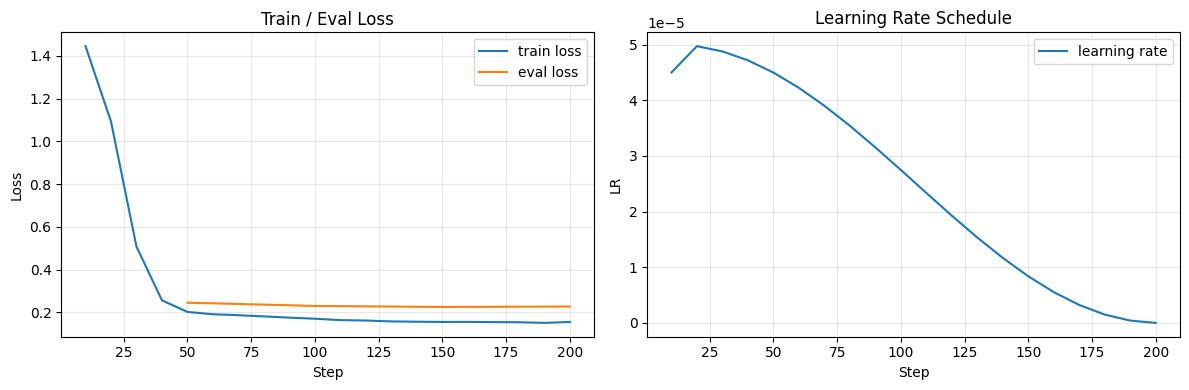

In [8]:
import matplotlib.pyplot as plt
from collections import defaultdict

log_history = trainer.state.log_history
series = defaultdict(lambda: {'step': [], 'value': []})

for entry in log_history:
    step = entry.get('step')
    for key, value in entry.items():
        if key in {'loss', 'eval_loss', 'learning_rate'} and step is not None:
            series[key]['step'].append(step)
            series[key]['value'].append(value)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if series['loss']['step']:
    axes[0].plot(series['loss']['step'], series['loss']['value'], label='train loss')
if series['eval_loss']['step']:
    axes[0].plot(series['eval_loss']['step'], series['eval_loss']['value'], label='eval loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train / Eval Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

if series['learning_rate']['step']:
    axes[1].plot(series['learning_rate']['step'], series['learning_rate']['value'], label='learning rate')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('LR')
axes[1].set_title('Learning Rate Schedule')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Save The Best-Loaded Adapter

If `load_best_model_at_end=True` is supported by the installed TRL stack, the in-memory model should already be the best validation checkpoint here.


In [9]:
ADAPTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(ADAPTER_OUTPUT_DIR))
tokenizer.save_pretrained(str(ADAPTER_OUTPUT_DIR))
print('saved_adapter_dir=', ADAPTER_OUTPUT_DIR)
print('best_checkpoint_dir=', getattr(trainer.state, 'best_model_checkpoint', None))


saved_adapter_dir= /root/aditya/agentic-traffic/artifacts/district_llm_adapter_v3/main_run/adapter
best_checkpoint_dir= /root/aditya/agentic-traffic/artifacts/district_llm_adapter_v3/main_run/checkpoints/checkpoint-150


In [10]:
from unsloth import FastLanguageModel

LOADABLE_MODEL_DIR = Path(getattr(trainer.state, 'best_model_checkpoint', '') or ADAPTER_OUTPUT_DIR)
if not LOADABLE_MODEL_DIR.exists():
    LOADABLE_MODEL_DIR = ADAPTER_OUTPUT_DIR

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(LOADABLE_MODEL_DIR),
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=LOAD_IN_4BIT,
)

FastLanguageModel.for_inference(model)
print('loaded_model_dir=', LOADABLE_MODEL_DIR)


==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 5.2.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


/root/conda_envs/traffic-llm/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=23524) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
Loading weights: 100%|██████████| 291/291 [00:00<00:00, 318.30it/s, Materializing param=model.norm.weight]                              


loaded_model_dir= /root/aditya/agentic-traffic/artifacts/district_llm_adapter_v3/main_run/checkpoints/checkpoint-150


## 8. Quick Inference Sanity Check

Run a short generation on validation messages before the offline evaluation pass.


In [11]:
from transformers import TextStreamer

FastLanguageModel.for_inference(model)
sample_messages = dataset['val'][0]['messages'][:2]
prompt = render_messages(sample_messages, add_generation_prompt=True)

inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
streamer = TextStreamer(tokenizer)
_ = model.generate(**inputs, max_new_tokens=128, do_sample=False, streamer=streamer)


<|begin_of_text|>system: You are a district traffic coordinator for RL traffic lights. Return only valid JSON with exactly these keys: strategy, priority_corridor, target_intersections, phase_bias, duration_steps. target_intersections must be a JSON array with at most 3 unique ids. If candidate_intersections is present, target_intersections must use only ids from that list. Do not invent intersection ids. Deduplicate ids. If uncertain, prefer the most congested valid candidates.
user: ### DISTRICT STATE
city_id: city_0009
district_id: d_03
district_type: residential
scenario: normal
scenario_type: moderate_rush
decision_step: 10
sim_time: 50
intersection_count: 18
avg_queue: 1.17
max_queue: 4.00
total_queue: 21.00
avg_wait: 0.22
max_wait: 1.00
total_wait: 4.00
avg_outgoing_load: 1.56
max_outgoing_load: 5.00
total_outgoing_load: 28.00
recent_throughput: 2.00
queue_change: 4.00
wait_change: 2.00
throughput_change: 0.00
ns_queue: 21.00
ew_queue: 0.00
ns_wait: 4.00
ew_wait: 0.00
dominant_f

--- Logging error ---
Traceback (most recent call last):
  File "/root/conda_envs/traffic-llm/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/root/conda_envs/traffic-llm/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/root/conda_envs/traffic-llm/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/root/conda_envs/traffic-llm/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/root/conda_envs/traffic-llm/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new

{"duration_steps": 10, "phase_bias": "NS", "priority_corridor": "inbound", "strategy": "clear_spillback", "target_intersections": ["i_0014", "i_0003", "i_0025"]}<|end_of_text|>


## 9. Offline Evaluation With Before/After Repair Metrics

This uses the updated offline evaluator to compare raw predictions against repaired predictions and optionally score only visible candidates.


In [12]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [13]:
from district_llm.eval import (
    DistrictTopologyIndex,
    evaluate_rows,
    load_rows,
    print_debug_examples,
)
from district_llm.repair import RepairConfig

FastLanguageModel.for_inference(model)
val_rows = load_rows(VAL_JSONL, max_examples=MAX_EVAL_EXAMPLES)
topology_index = DistrictTopologyIndex(REPO_ROOT / 'data' / 'generated')

results = evaluate_rows(
    rows=val_rows,
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=128,
    topology_index=topology_index,
    restrict_targets_to_visible_summary=RESTRICT_TARGETS_TO_VISIBLE_SUMMARY,
    debug_examples=DEBUG_EXAMPLES,
    repair_config=RepairConfig(
        allow_only_visible_candidates=ALLOW_ONLY_VISIBLE_CANDIDATES,
        max_target_intersections=MAX_TARGET_INTERSECTIONS,
        fallback_on_empty_targets=FALLBACK_ON_EMPTY_TARGETS,
        fallback_mode=FALLBACK_MODE,
    ),
    report_before_after_repair=True,
)

summary = {key: value for key, value in results.items() if key != 'debug_examples'}
print(json.dumps(summary, indent=2, sort_keys=True))


eval: 100%|██████████| 250/250 [06:22<00:00,  1.53s/it]

{
  "exact_full_object_accuracy": 0.632,
  "exact_full_object_accuracy_after_repair": 0.632,
  "field_accuracy": {
    "duration_steps": 1.0,
    "phase_bias": 0.92,
    "priority_corridor": 0.744,
    "strategy": 0.872
  },
  "field_accuracy_after_repair": {
    "duration_steps": 1.0,
    "phase_bias": 0.92,
    "priority_corridor": 0.744,
    "strategy": 0.872
  },
  "json_validity_rate": 1.0,
  "num_examples": 250,
  "schema_validity_rate": 1.0,
  "target_intersections": {
    "exact_list_match": 0.972,
    "exact_set_match": 0.972,
    "hit_at_1": 1.0,
    "hit_at_2": 1.0,
    "hit_at_3": 0.972,
    "jaccard": 0.986,
    "overlap_count": 2.972,
    "overlap_rate": 0.9906666666666666,
    "precision": 0.9906666666666666,
    "recall": 0.9906666666666666
  },
  "target_intersections_after_repair": {
    "exact_list_match": 0.972,
    "exact_set_match": 0.972,
    "hit_at_1": 1.0,
    "hit_at_2": 1.0,
    "hit_at_3": 0.972,
    "jaccard": 0.986,
    "overlap_count": 2.972,
    "overla

## 10. Inspect Debug Examples And Repair Behavior

This prints sample predictions before and after repair, then surfaces the failure buckets and repair usage.


In [14]:
print_debug_examples(results['debug_examples'])

print('Failure buckets:')
print(json.dumps(results.get('target_intersections_failure_buckets', {}), indent=2, sort_keys=True))

before_after = results.get('target_intersections_before_after_repair', {})
if before_after:
    print('Before/after repair summary:')
    print(json.dumps(before_after, indent=2, sort_keys=True))

for index, item in enumerate(results['debug_examples'][:3], start=1):
    print(f'\n[sample {index}] before_repair_targets=', item['predicted_json_parsed_before_repair'])
    print(f'[sample {index}] after_repair_targets=', item['predicted_json_parsed_after_repair'])
    print(f'[sample {index}] repair_report=', json.dumps(item['repair_report'], sort_keys=True))


[debug 1] district_summary:
### DISTRICT STATE
city_id: city_0009
district_id: d_03
district_type: residential
scenario: normal
scenario_type: moderate_rush
decision_step: 10
sim_time: 50
intersection_count: 18
avg_queue: 1.17
max_queue: 4.00
total_queue: 21.00
avg_wait: 0.22
max_wait: 1.00
total_wait: 4.00
avg_outgoing_load: 1.56
max_outgoing_load: 5.00
total_outgoing_load: 28.00
recent_throughput: 2.00
queue_change: 4.00
wait_change: 2.00
throughput_change: 0.00
ns_queue: 21.00
ew_queue: 0.00
ns_wait: 4.00
ew_wait: 0.00
dominant_flow: NS
boundary_queue_total: 12.00
boundary_wait_total: 2.00
spillback_risk: 0
incident_flag: 0
construction_flag: 0
overload_flag: 0
event_flag: 0
top_congested_intersections:
- i_0014 q=3.00 w=1.00 out=5.00 phase=0 boundary=1
- i_0003 q=2.00 w=1.00 out=4.00 phase=1 boundary=0
- i_0025 q=4.00 w=0.00 out=0.00 phase=1 boundary=1
candidate_intersections:
- i_0014 q=3.00 w=1.00 out=5.00 phase=0 boundary=1 spillback=1 incident=0 overload=0 event=0 align=NS reas

## 11. Optional: Evaluate The Saved Adapter From Disk

These commands mirror the notebook flow from the CLI for the final ablation run.


In [ ]:
# # Dataset generation
# # python scripts/generate_large_district_dataset.py
# #   --num-train 10000
# #   --num-val 2500
# #   --output-dir data/district_llm_dataset_v3
# #   --checkpoint artifacts/dqn_shared/best_validation.pt
# #   --max-candidate-intersections 6
# #   --max-target-intersections 3

# # Offline evaluation
# python -m district_llm.eval
#   --model-path artifacts/district_llm_adapter_v3/main_run/adapter
#   --val-jsonl data/district_llm_dataset_v3/val.jsonl
#   --generated-root data/generated
#   --max-examples=250
#   --debug-examples=10
#   --allow-only-visible-candidates
#   --max-target-intersections=3
#   --fallback-on-empty-targets
#   --fallback-mode heuristic
#   --restrict-targets-to-visible-summary
#   --report-before-after-repair


SyntaxError: invalid syntax (3839198296.py, line 11)